In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import re
import ast
from collections import Counter

print("Libraries loaded")

Libraries loaded


In [ ]:
#Load Data

path = '/content/drive/MyDrive/food-recommender/'

recipes = pd.read_csv(path + 'RAW_recipes.csv')
interactions = pd.read_csv(path + 'RAW_interactions.csv')

print("Recipes shape:", recipes.shape)
print("Interactions shape:", interactions.shape)
print("\nRecipes columns:", recipes.columns.tolist())
print("Interactions columns:", interactions.columns.tolist())

Recipes shape: (231637, 12)
Interactions shape: (1132367, 5)

Recipes columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']
Interactions columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']


In [ ]:
print("Recipes First 5 Rows:")
print(recipes.head())
print("\nInteractions First 5 Rows:")
print(interactions.head())

Recipes First 5 Rows:
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            a bit different  breakfast pizza   31490       30   
2                   all in the kitchen  chili  112140      130   
3                          alouette  potatoes   59389       45   
4          amish  tomato ketchup  for canning   44061      190   

   contributor_id   submitted  \
0           47892  2005-09-16   
1           26278  2002-06-17   
2          196586  2005-02-25   
3           68585  2003-04-14   
4           41706  2002-10-25   

                                                tags  \
0  ['60-minutes-or-less', 'time-to-make', 'course...   
1  ['30-minutes-or-less', 'time-to-make', 'course...   
2  ['time-to-make', 'course', 'preparation', 'mai...   
3  ['60-minutes-or-less', 'time-to-make', 'course...   
4  ['weeknight', 'time-to-make', 'course', 'main-...   

                                    nutrition

In [ ]:
print("Missing Values in Recipes:")
print(recipes.isnull().sum())
print("\nMissing Values in Interactions:")
print(interactions.isnull().sum())

Missing Values in Recipes:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

Missing Values in Interactions:
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64


In [ ]:
print("Recipe Statistics:")
print(recipes[['minutes', 'n_ingredients', 'n_steps']].describe())
print("\nRating Statistics:")
print(interactions['rating'].describe())

Recipe Statistics:
            minutes  n_ingredients        n_steps
count  2.316370e+05  231637.000000  231637.000000
mean   9.398546e+03       9.051153       9.765499
std    4.461963e+06       3.734796       5.995128
min    0.000000e+00       1.000000       0.000000
25%    2.000000e+01       6.000000       6.000000
50%    4.000000e+01       9.000000       9.000000
75%    6.500000e+01      11.000000      12.000000
max    2.147484e+09      43.000000     145.000000

Rating Statistics:
count    1.132367e+06
mean     4.411016e+00
std      1.264752e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


/tmp/ipykernel_745/566910260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=interactions, palette='Reds')


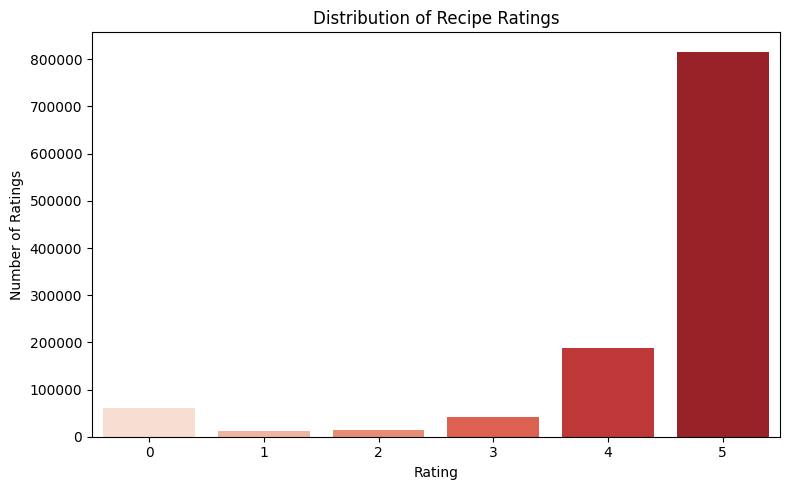

Graph saved


In [ ]:
#EDA

plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=interactions, palette='Reds')
plt.title('Distribution of Recipe Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig(path + 'rating_distribution.png')
plt.show()
print("Graph saved")

/tmp/ipykernel_745/657414678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ingredient', data=ingredients_df, palette='Reds_r')


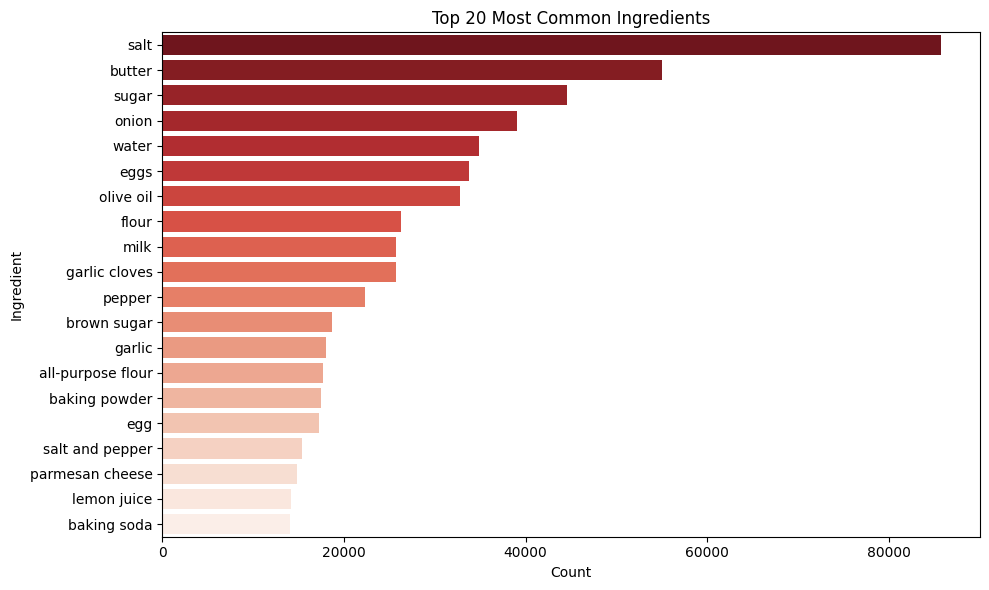

Graph saved


In [ ]:
recipes['ingredients_list'] = recipes['ingredients'].apply(ast.literal_eval)
all_ingredients = [item for sublist in recipes['ingredients_list'] for item in sublist]
ingredient_counts = Counter(all_ingredients).most_common(20)
ingredients_df = pd.DataFrame(ingredient_counts, columns=['ingredient', 'count'])

plt.figure(figsize=(10,6))
sns.barplot(x='count', y='ingredient', data=ingredients_df, palette='Reds_r')
plt.title('Top 20 Most Common Ingredients')
plt.xlabel('Count')
plt.ylabel('Ingredient')
plt.tight_layout()
plt.savefig(path + 'top_ingredients.png')
plt.show()
print("Graph saved")

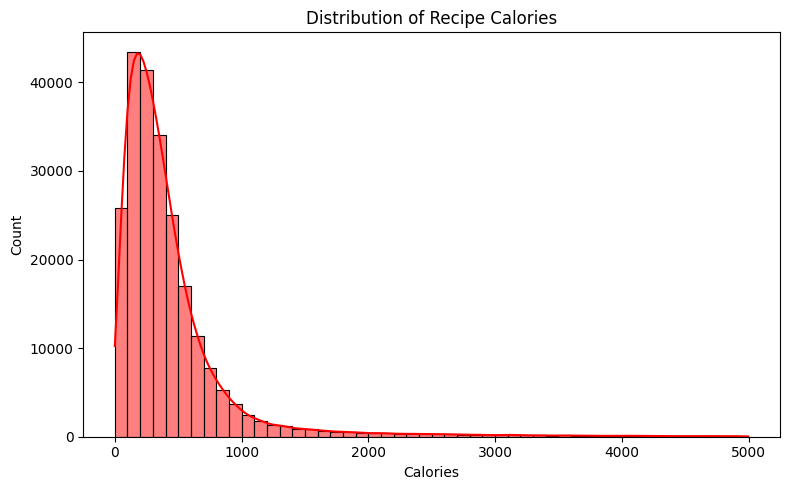

Graph saved


In [ ]:
recipes['nutrition_list'] = recipes['nutrition'].apply(ast.literal_eval)
recipes['calories'] = recipes['nutrition_list'].apply(lambda x: x[0])
calories_filtered = recipes[recipes['calories'] < 5000]

plt.figure(figsize=(8,5))
sns.histplot(calories_filtered['calories'], bins=50, color='red', kde=True)
plt.title('Distribution of Recipe Calories')
plt.xlabel('Calories')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(path + 'calorie_distribution.png')
plt.show()
print("Graph saved")

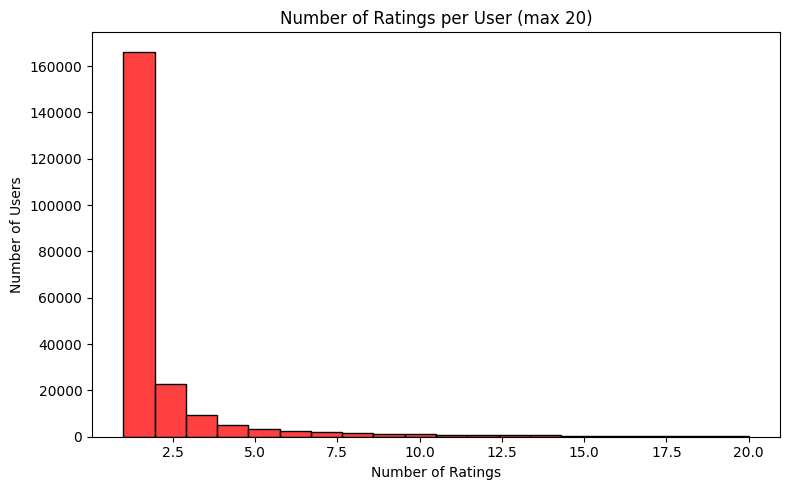

Graph saved


In [ ]:
user_interaction_counts = interactions.groupby('user_id').size()

plt.figure(figsize=(8,5))
user_counts = user_interaction_counts[user_interaction_counts <= 20]
sns.histplot(user_counts, bins=20, color='red')
plt.title('Number of Ratings per User (max 20)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(path + 'user_interactions.png')
plt.show()
print("Graph saved")

In [ ]:
print("=" * 45)
print("        EDA SUMMARY")
print("=" * 45)
print(f"Total recipes:              {len(recipes):,}")
print(f"Total interactions:         {len(interactions):,}")
print(f"Total unique users:         {interactions['user_id'].nunique():,}")
print(f"\n--- Issues Found ---")
print(f"Invalid ratings (0):        {len(interactions[interactions['rating']==0]):,} (5.37%)")
print(f"Recipes with 0 mins:        {len(recipes[recipes['minutes']==0]):,}")
print(f"Recipes over 300 mins:      {len(recipes[recipes['minutes']>300]):,}")
print(f"Users under 3 ratings:      188,994 (83%)")
print(f"Missing descriptions:       4,979")
print(f"\n--- Cleaning Plan ---")
print(f"Remove rating = 0")
print(f"Keep recipes 1-300 mins")
print(f"Remove users with < 3 ratings")
print(f"Like = rating >= 4")
print(f"Not Like = rating 1-3")
print("=" * 45)

        EDA SUMMARY
Total recipes:              231,637
Total interactions:         1,132,367
Total unique users:         226,570

--- Issues Found ---
Invalid ratings (0):        60,847 (5.37%)
Recipes with 0 mins:        1,094
Recipes over 300 mins:      9,970
Users under 3 ratings:      188,994 (83%)
Missing descriptions:       4,979

--- Cleaning Plan ---
Remove rating = 0
Keep recipes 1-300 mins
Remove users with < 3 ratings
Like = rating >= 4
Not Like = rating 1-3


In [ ]:
#Preprocessing & Cleaning

# Remove rating = 0
interactions_clean = interactions[interactions['rating'] > 0]
print(f"After removing rating=0: {len(interactions_clean):,} rows")

# Remove users with less than 3 ratings
user_counts = interactions_clean.groupby('user_id').size()
valid_users = user_counts[user_counts >= 3].index
interactions_clean = interactions_clean[interactions_clean['user_id'].isin(valid_users)]
print(f"After removing users < 3 ratings: {len(interactions_clean):,} rows")

# Remove recipes with 0 or over 300 mins
recipes_clean = recipes[(recipes['minutes'] > 0) & (recipes['minutes'] <= 300)]
print(f"After filtering cooking time: {len(recipes_clean):,} recipes")

# Remove calorie outliers
recipes_clean = recipes_clean[
    (recipes_clean['calories'] >= 10) &
    (recipes_clean['calories'] <= 2000)
]
print(f"After filtering calories: {len(recipes_clean):,} recipes")

# Merge
merged = interactions_clean.merge(
    recipes_clean[['id','name','ingredients','calories','minutes']],
    left_on='recipe_id',
    right_on='id'
)
print(f"After merging: {len(merged):,} rows")
print("\nPreprocessing complete")

After removing rating=0: 1,071,520 rows
After removing users < 3 ratings: 890,570 rows
After filtering cooking time: 220,573 recipes
After filtering calories: 213,759 recipes
After merging: 820,876 rows

Preprocessing complete


In [ ]:
merged['label'] = merged['rating'].apply(lambda x: 1 if x >= 4 else 0)

print("=== LABEL DISTRIBUTION ===")
print(merged['label'].value_counts())
print("\nLike %:", round(merged['label'].mean() * 100, 2), "%")
print("Not Like %:", round((1 - merged['label'].mean()) * 100, 2), "%")

=== LABEL DISTRIBUTION ===
label
1    776756
0     44120
Name: count, dtype: int64

Like %: 94.63 %
Not Like %: 5.37 %


In [ ]:
def clean_ingredients(ingredient_str):
    ingredients = ast.literal_eval(ingredient_str)
    cleaned = ' '.join(ingredients).lower()
    cleaned = re.sub(r'[^a-zA-Z\s]', '', cleaned)
    return cleaned

merged['ingredients_clean'] = merged['ingredients'].apply(clean_ingredients)
print("Sample cleaned ingredients:")
print(merged['ingredients_clean'].head(3).tolist())
print("\nCleaning complete")

Sample cleaned ingredients:
['devils food cake mix vegetable oil eggs reeses pieces', 'raspberries granulated sugar', 'chicken tenders flour garlic powder salt ground pepper buttermilk vegetable oil hickory flavored barbecue sauce water honey ketchup liquid smoke']

Cleaning complete


In [ ]:
#Fix imbalanced data
from sklearn.utils import resample

like = merged[merged['label'] == 1]
not_like = merged[merged['label'] == 0]

print(f"Before balancing:")
print(f"Like: {len(like):,}")
print(f"Not Like: {len(not_like):,}")

like_downsampled = resample(like,
                            replace=False,
                            n_samples=len(not_like),
                            random_state=42)

balanced = pd.concat([like_downsampled, not_like])
balanced = balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAfter balancing:")
print(balanced['label'].value_counts())
print(f"Total rows: {len(balanced):,}")

Before balancing:
Like: 776,756
Not Like: 44,120

After balancing:
label
1    44120
0    44120
Name: count, dtype: int64
Total rows: 88,240


In [ ]:
#TF-IDF + features

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp

# Average recipe rating feature
avg_recipe_rating = interactions_clean.groupby('recipe_id')['rating'].mean().reset_index()
avg_recipe_rating.columns = ['recipe_id', 'avg_recipe_rating']
balanced = balanced.merge(avg_recipe_rating, on='recipe_id', how='left')
balanced['avg_recipe_rating'] = balanced['avg_recipe_rating'].fillna(3.0)

# TF-IDF
tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(balanced['ingredients_clean'])

# Numeric features
numeric_features = balanced[['calories', 'minutes', 'avg_recipe_rating']].values
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_features)
numeric_sparse = sp.csr_matrix(numeric_scaled)

# Combine
X = sp.hstack([X_tfidf, numeric_sparse])
y = balanced['label'].values

print(f"Feature matrix shape: {X.shape}")
print("TF-IDF complete")

Feature matrix shape: (88240, 503)
TF-IDF complete


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Testing set:    {X_test.shape[0]:,} rows")
print("Split complete")

Training set:   70,592 rows
Testing set:    17,648 rows
Split complete


In [ ]:
#Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Logistic Regression
print("Training Logistic Regression...")
start = time.time()
lr_model = LogisticRegression(max_iter=3000, random_state=42, solver='saga')
lr_model.fit(X_train, y_train)
print(f"Training time: {round(time.time()-start, 2)} seconds")
lr_pred = lr_model.predict(X_test)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {round(accuracy_score(y_test, lr_pred)*100,2)}%")
print(f"Precision: {round(precision_score(y_test, lr_pred)*100,2)}%")
print(f"Recall:    {round(recall_score(y_test, lr_pred)*100,2)}%")
print(f"F1 Score:  {round(f1_score(y_test, lr_pred)*100,2)}%")

# Random Forest
print("\nTraining Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f"Training time: {round(time.time()-start, 2)} seconds")
rf_pred = rf_model.predict(X_test)

print("\n=== RANDOM FOREST RESULTS ===")
print(f"Accuracy:  {round(accuracy_score(y_test, rf_pred)*100,2)}%")
print(f"Precision: {round(precision_score(y_test, rf_pred)*100,2)}%")
print(f"Recall:    {round(recall_score(y_test, rf_pred)*100,2)}%")
print(f"F1 Score:  {round(f1_score(y_test, rf_pred)*100,2)}%")

Training Logistic Regression...
Training time: 6.28 seconds

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  75.82%
Precision: 72.82%
Recall:    82.4%
F1 Score:  77.31%

Training Random Forest...
Training time: 384.35 seconds

=== RANDOM FOREST RESULTS ===
Accuracy:  72.21%
Precision: 73.92%
Recall:    68.63%
F1 Score:  71.18%


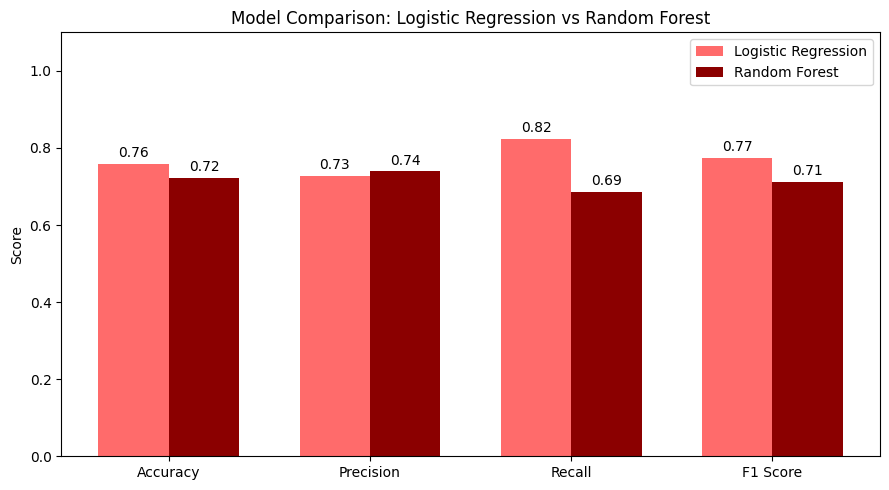

Graph saved


In [ ]:
#Model Comparison

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred)
]
rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#ff6b6b')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#8B0000')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(path + 'model_comparison.png')
plt.show()
print("Graph saved")

In [ ]:
#Save models

# Save Logistic Regression (chosen model)
pickle.dump(lr_model, open(path + 'model.pkl', 'wb'))
print("model.pkl saved")

# Save TF-IDF vectorizer
pickle.dump(tfidf, open(path + 'tfidf.pkl', 'wb'))
print("tfidf.pkl saved")

# Save scaler
pickle.dump(scaler, open(path + 'scaler.pkl', 'wb'))
print("scaler.pkl saved")

# Save cleaned recipes with steps
recipes_final = recipes_clean[['id','name','ingredients','calories','minutes','steps']].copy()
recipes_final = recipes_final.merge(avg_recipe_rating,
                                     left_on='id',
                                     right_on='recipe_id',
                                     how='left')
recipes_final['avg_recipe_rating'] = recipes_final['avg_recipe_rating'].fillna(3.0)
recipes_final['ingredients_clean'] = recipes_final['ingredients'].apply(clean_ingredients)

# Filter to reduce file size
recipes_final = recipes_final[
    recipes_final['avg_recipe_rating'] >= 4.0
][['id','name','ingredients','calories','minutes','steps','avg_recipe_rating','ingredients_clean']]

recipes_final = recipes_final.sample(frac=0.7, random_state=42).reset_index(drop=True)

recipes_final = recipes_final.drop(columns=['ingredients_clean'])

pickle.dump(recipes_final, open(path + 'recipes.pkl', 'wb'))
size = os.path.getsize(path + 'recipes.pkl')
print(f"recipes.pkl size: {round(size/1024/1024, 1)} MB")

pickle.dump(recipes_final, open(path + 'recipes.pkl', 'wb'))
print("recipes.pkl saved")

size = os.path.getsize(path + 'recipes.pkl')
print(f"\nrecipes.pkl size: {round(size/1024/1024, 1)} MB")
print("\n=== ALL FILES SAVED ===")
print(os.listdir(path))

model.pkl saved
tfidf.pkl saved
scaler.pkl saved
recipes.pkl size: 93.4 MB
recipes.pkl saved

recipes.pkl size: 93.4 MB

=== ALL FILES SAVED ===
['RAW_interactions.csv', 'RAW_recipes.csv', 'rating_distribution.png', 'top_ingredients.png', 'calorie_distribution.png', 'user_interactions.png', 'model_comparison.png', 'model.pkl', 'tfidf.pkl', 'scaler.pkl', 'recipes.pkl']
